## Imports

In [32]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Directories

In [ ]:
CURATED_DIR = "../../data/curated"

REPORT_DIR = "../reports/models"
IMAGE_DIR = "../reports/models/images"

os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

## Load Historical Dataset

In [34]:
df = pd.read_parquet(
    f"{CURATED_DIR}/environmental_master.parquet"
)

df["datetime"] = pd.to_datetime(
    df["datetime"]
)

print(df.shape)

df.head()

(508116, 20)


,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-01-01 21:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,123,66.79,109.32,71.50,18.09,15.6,87,13.4,0.0,1018.4,48,7.6,315,11.2
1,2022-01-01 21:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,193,87.98,173.04,72.72,18.48,16.2,81,13.0,0.0,1018.6,18,7.4,331,12.6
2,2022-01-01 21:00:00,WB015,Sarsuna College,Kolkata,22.481270,88.284554,185,85.59,194.13,73.95,18.51,16.8,78,12.9,0.0,1018.7,57,7.4,317,13.3
3,2022-01-01 22:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,145,73.56,156.15,75.74,17.73,15.4,88,13.5,0.0,1018.3,100,7.4,321,11.2
4,2022-01-01 22:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,231,99.37,168.51,75.08,18.05,15.6,85,13.1,0.0,1018.4,74,7.1,330,11.2


In [35]:
df = df.sort_values(
    ["station_id", "datetime"]
).reset_index(drop=True)

df.head()

,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-03-14 21:00:00,WB001,Avidipta Housing Complex,Kolkata,22.493217,88.39831,309,99.84,356.97,46.72,29.36,26.4,45,13.6,0.0,1009.2,0,3.3,96,3.6
1,2022-03-14 22:00:00,WB001,Avidipta Housing Complex,Kolkata,22.493217,88.39831,247,93.26,297.28,47.72,29.12,23.8,55,14.2,0.0,1009.1,0,6.4,117,6.8
2,2022-03-14 23:00:00,WB001,Avidipta Housing Complex,Kolkata,22.493217,88.39831,237,101.19,267.28,48.98,28.76,21.8,63,14.4,0.0,1008.5,0,8.4,137,9.7
3,2022-03-15 00:00:00,WB001,Avidipta Housing Complex,Kolkata,22.493217,88.39831,232,99.72,281.34,50.03,28.57,21.1,65,14.2,0.0,1008.1,0,7.7,169,10.8
4,2022-03-15 01:00:00,WB001,Avidipta Housing Complex,Kolkata,22.493217,88.39831,234,100.31,274.43,54.69,27.55,21.0,64,14.0,0.0,1007.3,0,6.4,196,10.1


## Time Features

In [36]:
df["hour"] = df["datetime"].dt.hour

df["day_of_week"] = (
    df["datetime"].dt.dayofweek
)

df["month"] = (
    df["datetime"].dt.month
)

df["year"] = (
    df["datetime"].dt.year
)

##  Add Cyclical Features

In [37]:
# Hour cyclical encoding

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Month cyclical encoding

df["month_sin"] = np.sin(
    2 * np.pi * df["month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month"] / 12
)

## Season Feature

In [38]:
def get_season(month):

    if month in [3, 4, 5]:
        return 1

    elif month in [6, 7, 8, 9]:
        return 2

    return 3


df["season"] = (
    df["month"]
    .apply(get_season)
)

df["season"].value_counts()

season
3    213181
2    153183
1    141752
Name: count, dtype: int64

## Station Encoding

In [39]:
df["station_code"] = (
    df["station_id"]
    .astype("category")
    .cat.codes
)

df[
    ["station_id", "station_code"]
].drop_duplicates().head()

,station_id,station_code
0,WB001,0
36115,WB002,1
63717,WB003,2
79555,WB004,3
106737,WB005,4


## PM2.5 Lag Features

In [40]:
lag_hours = [
    1,
    3,
    6,
    12,
    24,
    48,
    72,
    168
]

for lag in lag_hours:

    df[f"lag_{lag}"] = (

        df
        .groupby("station_id")["pm25"]
        .shift(lag)

    )

print("PM2.5 Lag Features Created")

PM2.5 Lag Features Created


## Rolling Features

In [41]:
df["rolling_mean_6"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            6,
            min_periods=1
        ).mean()
    )
)

df["rolling_mean_12"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            12,
            min_periods=1
        ).mean()
    )
)

df["rolling_mean_24"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            24,
            min_periods=1
        ).mean()
    )
)

df["rolling_std_24"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            24,
            min_periods=1
        ).std()
    )
)

df["rolling_max_24"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            24,
            min_periods=1
        ).max()
    )
)

df["rolling_min_24"] = (

    df.groupby("station_id")["pm25"]

    .transform(
        lambda x: x.rolling(
            24,
            min_periods=1
        ).min()
    )
)

## Forecast Horizon Construction

In [42]:
forecast_hours = 24

df["target"] = (
    df.groupby("station_id")["pm25"]
    .shift(-forecast_hours)
)

df = df.dropna()

print(df.shape)

(504852, 45)


## Removing Missing Rows

In [43]:
before = len(df)

df = df.dropna()

after = len(df)

print("Removed:", before - after)
print("Remaining:", after)

Removed: 0
Remaining: 504852


## Feature Selection

In [44]:
features = [

    "pm25",
    "pm10",

    "temperature_2m",
    "dew_point_2m",

    "surface_pressure",

    "cloud_cover",

    "wind_speed_10m",
    "wind_gusts_10m",

    "station_code",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "season",

    "lag_1",
    "lag_3",
    "lag_6",
    "lag_12",
    "lag_24",

    "lag_48",
    "lag_72",
    "lag_168",

    "rolling_mean_6",
    "rolling_mean_12",
    "rolling_mean_24",

    "rolling_std_24",
    "rolling_max_24",
    "rolling_min_24"
]

## Time-Based Train / Validation / Test Split

In [45]:
train = df[
    df["datetime"] < "2025-01-01"
]

validation = df[
    (df["datetime"] >= "2025-01-01")
    &
    (df["datetime"] < "2026-01-01")
]

test = df[
    df["datetime"] >= "2026-01-01"
]

print(train.shape)
print(validation.shape)
print(test.shape)

(305274, 45)
(143755, 45)
(55823, 45)


In [46]:
X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(305274, 28)
(143755, 28)
(55823, 28)


## Evaluation Function

In [47]:
def evaluate_model(
    name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {

        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)

    }

## Model 1 - Linear Regression

In [48]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

lr_results = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

lr_results

{'Model': 'Linear Regression',
 'MAE': 7.99,
 'RMSE': np.float64(11.439),
 'R2': 0.696}

## Model 2 - Random Forest

In [49]:
rf = RandomForestRegressor(

    n_estimators=200,
    max_depth=20,

    random_state=42,
    n_jobs=-1

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_results

{'Model': 'Random Forest',
 'MAE': 8.161,
 'RMSE': np.float64(11.593),
 'R2': 0.688}

## Model 3 - XGBoost

In [50]:
xgb = XGBRegressor(

    n_estimators=500,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_metrics = evaluate_model(
    "XGBoost_PM25",
    y_test,
    xgb_pred
)

xgb_metrics

{'Model': 'XGBoost_PM25',
 'MAE': 7.934,
 'RMSE': np.float64(11.356),
 'R2': 0.701}

## Feature Importance

In [51]:
importance = pd.DataFrame({

    "feature": features,

    "importance":
        xgb.feature_importances_

})

importance = (

    importance

    .sort_values(
        "importance",
        ascending=False
    )

)

importance.to_csv(
    f"{REPORT_DIR}/pm25_feature_importance.csv",
    index=False
)

importance.head(20)

,feature,importance
22,rolling_mean_6,0.450894
0,pm25,0.269272
24,rolling_mean_24,0.084375
14,lag_1,0.064033
1,pm10,0.014982
18,lag_24,0.014320
26,rolling_max_24,0.011748
12,month_cos,0.009076
19,lag_48,0.009033
13,season,0.007887


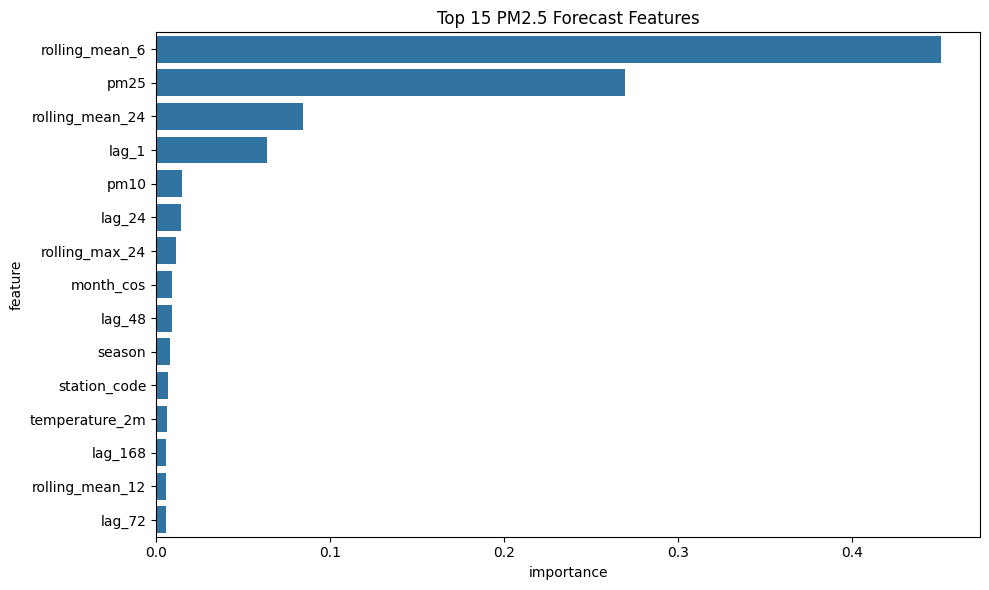

In [52]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(

    data=importance.head(15),

    x="importance",

    y="feature"

)

plt.title(
    "Top 15 PM2.5 Forecast Features"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/pm25_feature_importance.png",
    dpi=300
)

plt.show()

## Model Comparison

In [53]:
results_df = pd.DataFrame([

    lr_results,
    rf_results,
    xgb_metrics

])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,7.990,11.439,0.696
1,Random Forest,8.161,11.593,0.688
2,XGBoost_PM25,7.934,11.356,0.701


## Actual vs Predicted Plot Function

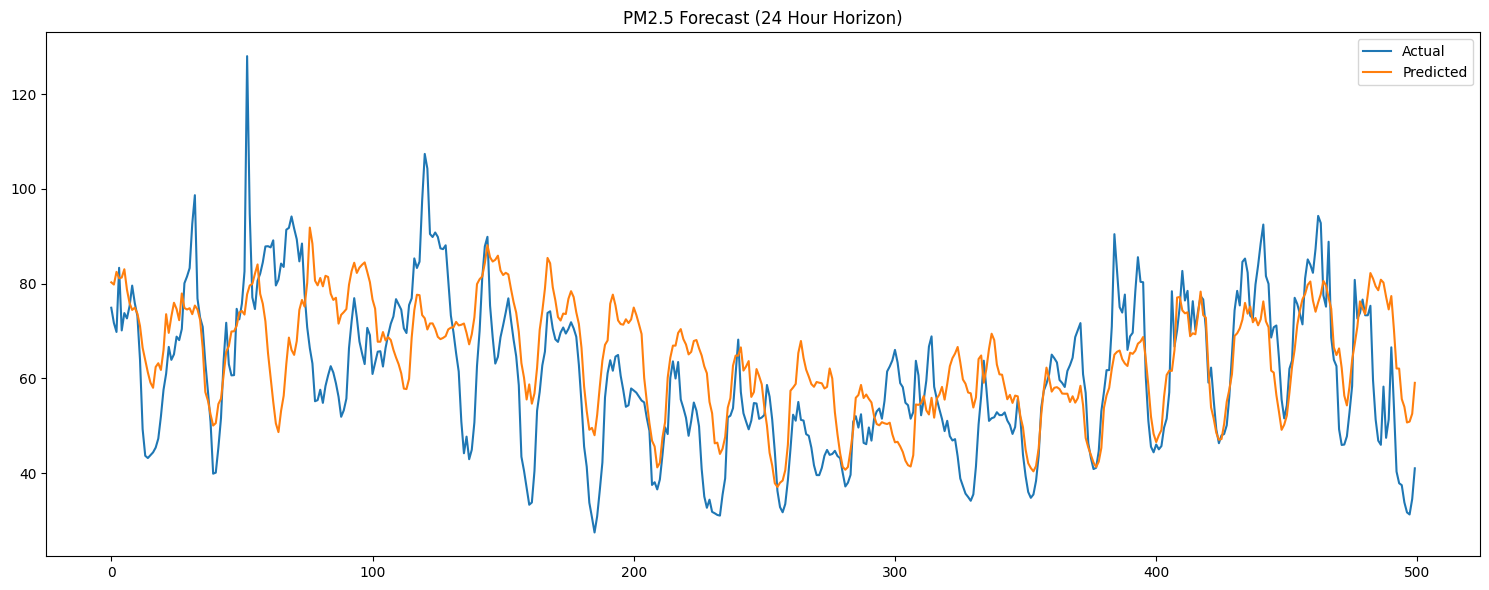

In [54]:
comparison = pd.DataFrame({

    "Actual":
        y_test.values[:500],

    "Predicted":
        xgb_pred[:500]
})

plt.figure(figsize=(15,6))

plt.plot(
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Predicted"],
    label="Predicted"
)

plt.legend()

plt.title(
    "PM2.5 Forecast (24 Hour Horizon)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/pm25_actual_vs_predicted.png",
    dpi=300
)

plt.show()

## LR Plot

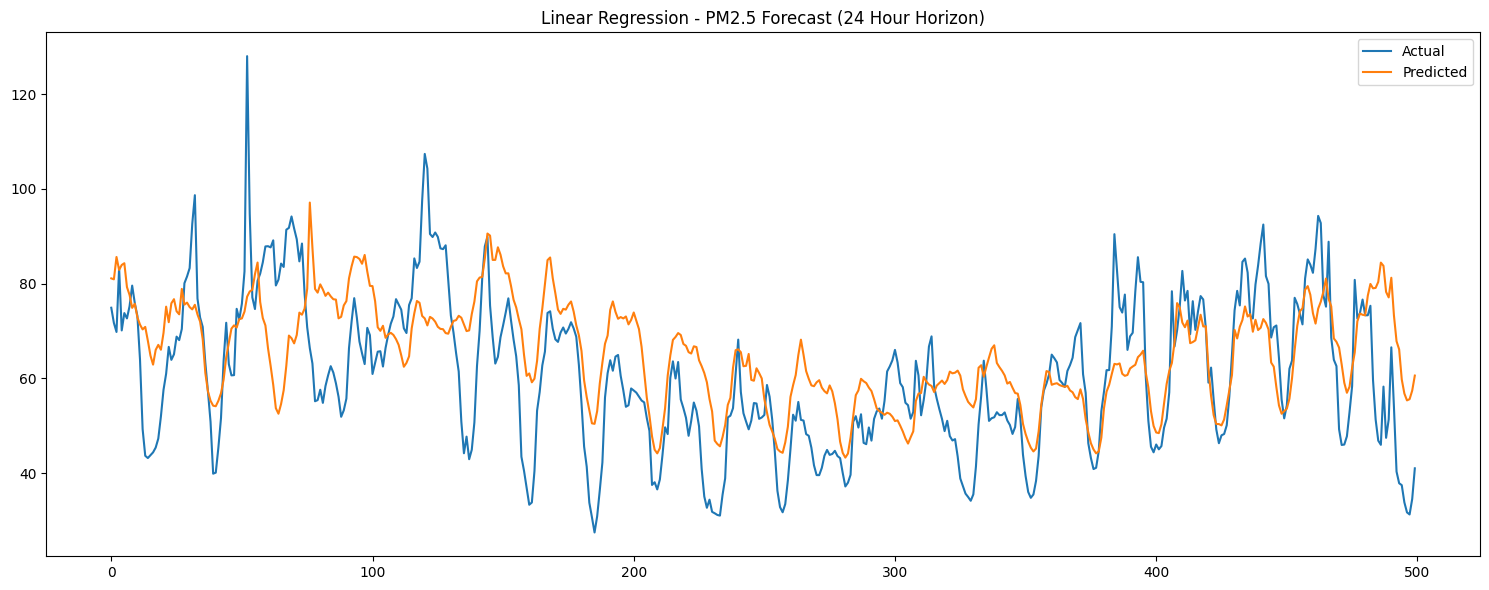

In [55]:
def save_prediction_plot(y_true, y_pred, model_name, filename, n_points=500):
    comparison = pd.DataFrame({
        "Actual": np.asarray(y_true)[:n_points],
        "Predicted": np.asarray(y_pred)[:n_points]
    })

    plt.figure(figsize=(15, 6))
    plt.plot(comparison["Actual"], label="Actual")
    plt.plot(comparison["Predicted"], label="Predicted")
    plt.legend()
    plt.title(f"{model_name} - PM2.5 Forecast (24 Hour Horizon)")
    plt.tight_layout()
    plt.savefig(f"{IMAGE_DIR}/{filename}", dpi=300)
    plt.show()

save_prediction_plot(
    y_test,
    lr_pred,
    "Linear Regression",
    "actual_vs_predicted_lr.png"
)

## RF Plot

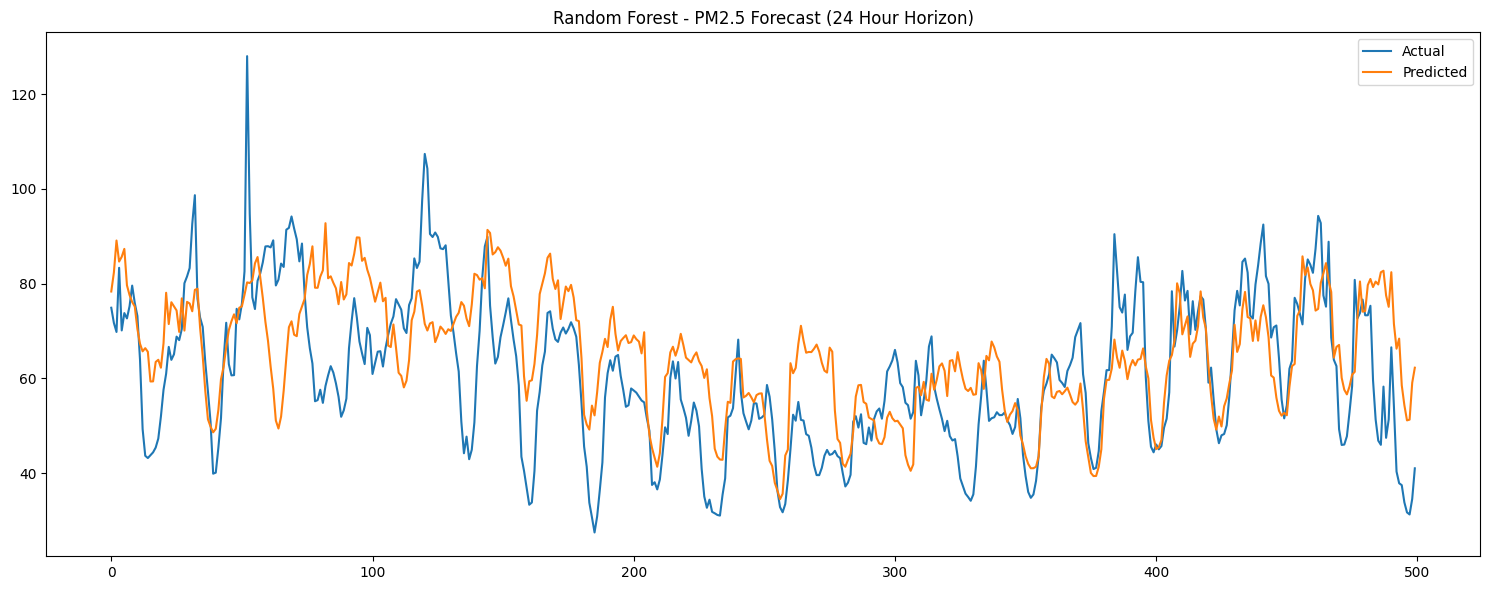

In [56]:
save_prediction_plot(
    y_test,
    rf_pred,
    "Random Forest",
    "actual_vs_predicted_rf.png"
)

## XGB Plot

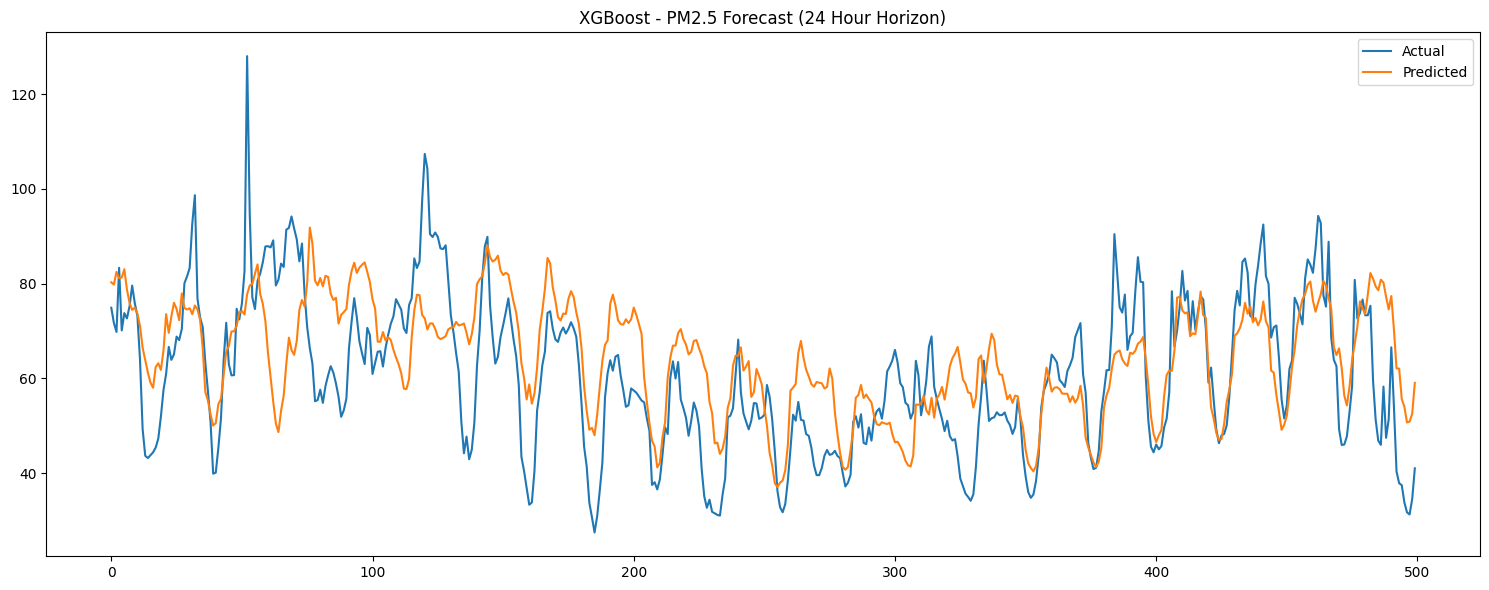

In [57]:
save_prediction_plot(
    y_test,
    xgb_pred,
    "XGBoost",
    "actual_vs_predicted_xgb.png"
)

## Model Comparison Chart

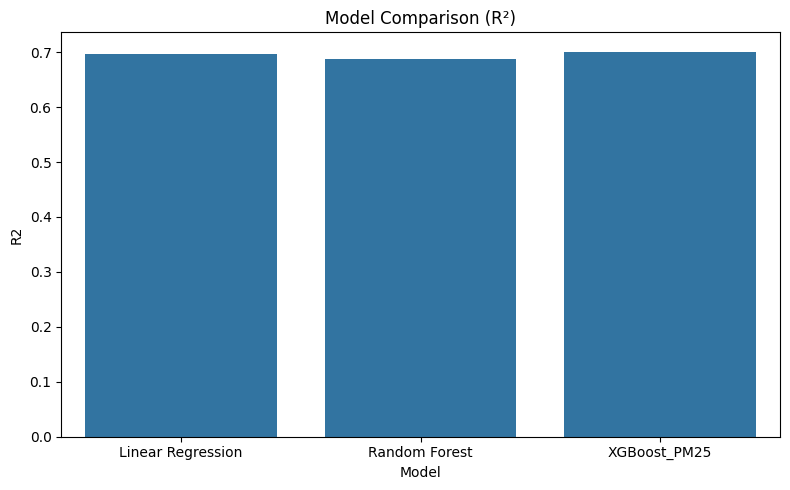

In [58]:
plt.figure(
    figsize=(8,5)
)

sns.barplot(
    data=results_df,
    x="Model",
    y="R2"

)

plt.title(
    "Model Comparison (R²)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/model_comparison.png",
    dpi=300
)

plt.show()